In [6]:
import numpy as np
import matplotlib.pyplot as plt
import RF_Track as rft
from scipy.optimize import minimize, curve_fit
from partrec_gaussian_optimiser_utils import partrec_gaussian_optimiser_utils
from topasToDose import getDosemap
from uniformity_fit import *
from partrec_foil_plotting import partrec_foil_plotting
from RF_track_utils import *
from flatness import *
from design_optimisation import get_s2_params, build_scatterer_lattice, scatterer_merit
import os
import csv
from YAG_RCF_analysis import *
from topasToDose import BinnedResult

In [8]:

mass = rft.electronmass    # particle mass in MeV/c^2
population = 10 * rft.nC               # number of particles per bunch                         # particle charge in e units
P_ref = 250
N_particles = int(500000)
charge = -1


# x, y, xp, yp = (rft.qrandn(N_particles, 4) * [1, 1, 0.01, 0.01]).T


# P = np.ones(N_particles) * P_ref
# T = np.zeros(N_particles)
# matrix = np.column_stack((x, xp, y, yp, T, P)) #transpose to match Bunch6d format
# B0 = rft.Bunch6d(mass, N_particles, charge, matrix)

Twiss = rft.Bunch6d_twiss()

Twiss.beta_x = 1450        # m
Twiss.beta_y = 2000      # m
Twiss.alpha_x = 0
Twiss.alpha_y = 0
Twiss.emitt_x = 17.3/1000 * (P_ref / mass)    # mm.mrad normalised emittance
Twiss.emitt_y = 12.3/1000 * (P_ref / mass)     # mm.mrad
if P_ref == 200:
    Twiss.beta_x = 1073        # m
    Twiss.beta_y = 1300      # m
    Twiss.alpha_x = 0
    Twiss.alpha_y = 0
    Twiss.emitt_x = 22.8/1000 * (P_ref / mass)    # mm.mrad normalised emittance
    Twiss.emitt_y = 19.2/1000 * (P_ref / mass)     # mm.mrad
elif P_ref ==250:
    Twiss.beta_x = 7325       # m
    Twiss.beta_y = 1813      # m
    Twiss.alpha_x = 0
    Twiss.alpha_y = 0
    Twiss.emitt_x = 2/1000 * (P_ref / mass)    # mm.mrad normalised emittance
    Twiss.emitt_y = 13.8/1000 * (P_ref / mass)     # mm.mrad
# Twiss.sigma_t = 10 * RF_Track.ps       # mm/c   or 37 * RF_Track.ps
# Twiss.sigma_pt = 10     # permille
Twiss.mean_xp = 0.0
Twiss.mean_yp = 0.0

B0 = rft.Bunch6d_QR(mass, population, charge, P_ref, Twiss, N_particles)      








In [ ]:
def loss (s2_pos, B0, target_size=16):  #16 target good for 10mm, 
    '''params dimensions in mm'''
    s2_l = get_s2_params(11, 38, 4, 1)[1]
    lattice = build_scatterer_lattice(11, 38, drift_to_s1=0, drift_to_s2=s2_pos,
                                      drift_to_phsp=1.18-s2_pos-sum(s2_l))

    B1 = lattice.track(B0)
    M = B1.get_phase_space('%x %xp %y %yp %E %z')

    x = M[:,0]
    y = M[:,2]
    count = np.sum(x**2 + y**2 < target_size**2)
    transmission_10mm = count / len(x)

    loss = scatterer_merit(M, target_size, size_weight=1, verbose=False)

    print('loss:', loss,  's2_pos:', s2_pos, 'transmission_10mm:', transmission_10mm)
    return loss

In [26]:
from scipy.optimize import minimize_scalar

opt_loss = np.inf

for i in range(5):
    res = minimize_scalar(
        loss,
        args=(B0_opt,),
        bounds=(0.01, 1.17),
        method='bounded',
        options={'xatol': 0.01}
    )

    if res.fun < opt_loss:
        opt_loss = res.fun
        opt_params = res.x

print(f'Trial: M={opt_loss:.3f}, param={opt_params}')


loss: 43.777729773519226 s2_pos: 0.4530805730501219 transmission_10mm: 0.0075
loss: 43.99085362013789 s2_pos: 0.7269194269498779 transmission_10mm: 0.0072
loss: 43.37423580363349 s2_pos: 0.28383885389975605 transmission_10mm: 0.0067
loss: 44.426262898807444 s2_pos: 0.17924171915036596 transmission_10mm: 0.0072
loss: 43.700379825796155 s2_pos: 0.3484834383007318 transmission_10mm: 0.0062
loss: 42.943861932564324 s2_pos: 0.24388630355134175 transmission_10mm: 0.0064
loss: 43.84069280336644 s2_pos: 0.21919426949878026 transmission_10mm: 0.0063
loss: 42.0693637759089 s2_pos: 0.25914681984719456 transmission_10mm: 0.0061
loss: 44.008519012932055 s2_pos: 0.2624801570242964 transmission_10mm: 0.0059
loss: 44.11374010015464 s2_pos: 0.25581348267009274 transmission_10mm: 0.0059
loss: 43.726466295079696 s2_pos: 0.4530805730501219 transmission_10mm: 0.0067
loss: 43.52755394615447 s2_pos: 0.7269194269498779 transmission_10mm: 0.0061
loss: 43.72794514655808 s2_pos: 0.8961611461002438 transmission_1

In [21]:
opt_params

np.float64(0.704266687786311)

Transmission in 10mm circle: 0.002682%


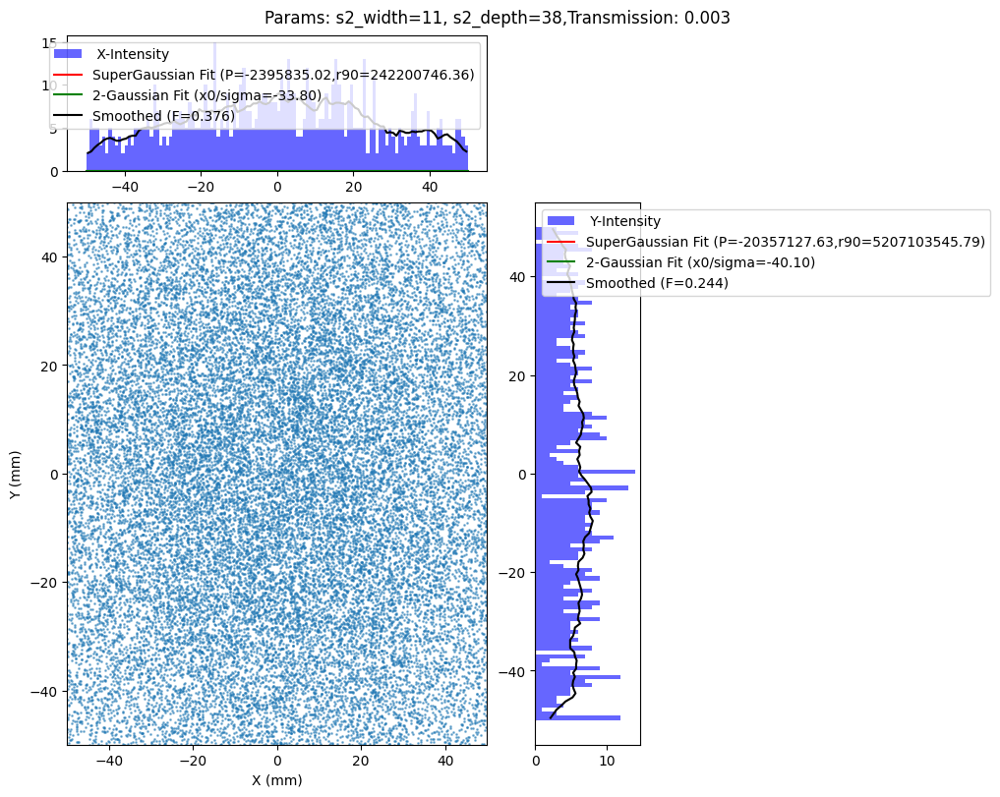

In [32]:

s2_pos = 1

# for s2_width in [11.5,12,12.5,13]:
#     for s2_depth in [3.5,4,4.5,5]:

lattice = rft.Lattice()
window = rft.Absorber(250e-6,'beryllium')
window.disable_energy_straggling()
window.set_shape ('circular', 0.5,0.5 )
lattice.append(window)

lattice.append(rft.Drift(s2_pos))  #drift to s1

# lattice.append(rft.Drift(0.5))  #drift to S2
# lattice.append(rft.Drift(0.532))  #drift to S2
s2_r,s2_l = get_s2_params(11,38, 4, 1)

for i in range(len(s2_l)):
    Slice = rft.Absorber(s2_l[i]/1000,31.9, 37, 288.31,1.32,-1)
    Slice.disable_energy_straggling()
    Slice.set_shape ('circular',  abs(s2_r[i])/1000,abs(s2_r[i])/1000 )
    lattice.append(Slice)

lattice.append(rft.Drift(1.18-s2_pos-sum(s2_l)))  #drift to phsp
# lattice.append(rft.Drift(0.5))

B1 = lattice.track(B0)
T = lattice.get_transport_table(
'%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')

M = B1.get_phase_space('%x %xp %y %yp %E %z')
x = M[:,0]
y = M[:,2]
count = np.sum(x**2 + y**2 < 10**2)
transmission_10mm = count / len(x)
print(f'Transmission in 10mm circle: {transmission_10mm}%')
plot_phsp(T,M,120,50,"Params: s2_width="+str(s2_width)+", s2_depth="+str(s2_depth)+",Transmission: "+str(round(transmission_10mm,3)))

In [ ]:
x = M[:,0]
y = M[:,2]
count = np.sum(x**2 + y**2 < 10**2)
transmission_10mm = count / len(x)
print(count, len(x), transmission_10mm)

checking results

checking with TOPAS

In [ ]:
#twiss to 6d params
Twiss.beta_x = 1450        # m
Twiss.beta_y = 2000      # m
Twiss.alpha_x = 0
Twiss.alpha_y = 0
Twiss.emitt_x = 17.3/1000 * (P_ref / mass)    # mm.mrad normalised emittance
Twiss.emitt_y = 12.3/1000 * (P_ref / mass)     # mm.mrad

if P_ref == 200:
    Twiss.beta_x = 1073        # m
    Twiss.beta_y = 1300      # m
    Twiss.alpha_x = 0
    Twiss.alpha_y = 0
    Twiss.emitt_x = 22.8/1000 * (P_ref / mass)    # mm.mrad normalised emittance
    Twiss.emitt_y = 19.2/1000 * (P_ref / mass)     # mm.mrad
elif P_ref ==250:
    Twiss.beta_x = 7325       # m
    Twiss.beta_y = 1813      # m
    Twiss.alpha_x = 0
    Twiss.alpha_y = 0
    Twiss.emitt_x = 2/1000 * (P_ref / mass)    # mm.mrad normalised emittance
    Twiss.emitt_y = 13.8/1000 * (P_ref / mass)     # mm.mrad
# Twiss.sigma_t = 10 * RF_Track.ps       # mm/c   or 37 * RF_Track.ps
# Twiss.sigma_pt = 10     # permille
Twiss.mean_xp = 0.0
Twiss.mean_yp = 0.0
# geo_emitt_x = Twiss.emitt_x / (P_ref / mass) #beta*gamma = p/mc
# geo_emitt_y = Twiss.emitt_y / (P_ref/ mass)
geo_emitt_x = 2/1000
geo_emitt_y = 13.8/1000
sig_x = np.sqrt(Twiss.beta_x * geo_emitt_x)
sig_y = np.sqrt(Twiss.beta_y * geo_emitt_y)
sig_xp = max(0.01, Twiss.alpha_x * np.sqrt(geo_emitt_x / Twiss.beta_x))
sig_yp = max(0.01, Twiss.alpha_y * np.sqrt(geo_emitt_y / Twiss.beta_y))
print('sig_x:', sig_x, 'sig_y:', sig_y, 'sig_xp:', sig_xp, 'sig_yp:', sig_yp)

sig_x: 4.080441152620633 sig_y: 5.001939623785957 sig_xp: 0.01 sig_yp: 0.01


In [12]:
output_filename='CLARA_250Q_full'
dose_depth=83
dir = '/Users/sabrinawang/Desktop/DPhil_Project/'
profile = "dose"
N_particles = int(1e6)

sig_x, sig_y, sig_xp, sig_yp = 5, 5, 0.01, 0.01

# s1_l, s2_width, s2_depth = 2.27403378, 3.80651473, 4.52916474 '''works great'''
# s2_width, s2_depth = 11,38
# s1_l, s2_width, s2_depth = res.x
# s1_l, s2_width, s2_depth = 4.91777743,  8.00924655, 12.33363883

setup = partrec_gaussian_optimiser_utils(world_material="Air")

setup.generate_phsp_beam(sig_x,sig_y,sig_xp,sig_yp,P_ref,0,N_particles)

setup.add_cylinder("window",0.25,0,300,"G4_Be",298.5)

s2_r = [11.,  8.25, 5.5,   2.75]
s2_l = [4.1417876,  8.57905608, 12.77353046, 12.50562586]

# constructing s2 from slices
s2_pos = 298.5+ 1000 - sum(s2_l) #position of base of s2 (largest slice)

for i in range(len(s2_l)):
    sname = 'S2_slice_' + str(i)
    slice_position = s2_pos + sum(s2_l[:i-1])   # sum of previous lengths
    setup.add_cylinder(sname, s2_l[i-1], 0, s2_r[i-1], 'PEEK', slice_position)


setup.add_cylinder('kapton',0.25, 0,33,"kapton",s2_pos+sum(s2_l))

setup.add_cylinder('tank_edge',0.8, 0,100,"PMMA",s2_pos + 499)

if profile == "dose":
    setup.add_tank_bins(s2_pos + 500, dose_depth, 100,100,dose_depth,output_filename,width=44)
elif profile == "intensity":
    # setup.add_patient(1191)
    setup.add_patient(s2_pos + 500)

setup.run_topas(view_setup=False)


Welcome to TOPAS, Tool for Particle Simulation (Version 3.9)
Loading parameters starting from: /Users/sabrinawang/Desktop/DPhil_Project/topas_main.txt

Geant4 Data directory has been specified by the
TOPAS_G4_DATA_DIR environment variable as /Applications/G4Data

**************************************************************
 Geant4 version Name: geant4-10-07-patch-03 [MT]   (19-November-2021)
  << in Multi-threaded mode >> 
                       Copyright : Geant4 Collaboration
                      References : NIM A 506 (2003), 250-303
                                 : IEEE-TNS 53 (2006), 270-278
                                 : NIM A 835 (2016), 186-225
                             WWW : http://geant4.org/
**************************************************************

TOPAS is in MT mode, setting number of threads to: 8

TOPAS set the tolerances based on the World size to:
      Surface tolerance = 0.05 nm, and radial tolerance = 0.05 nm.
/opt/anaconda3/envs/RFT_topas_bdsim/s

83


/Users/sabrinawang/Desktop/DPhil_Project/YAG_RCF_analysis.py:168: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax_main = plt.subplots(figsize=(10, 6))


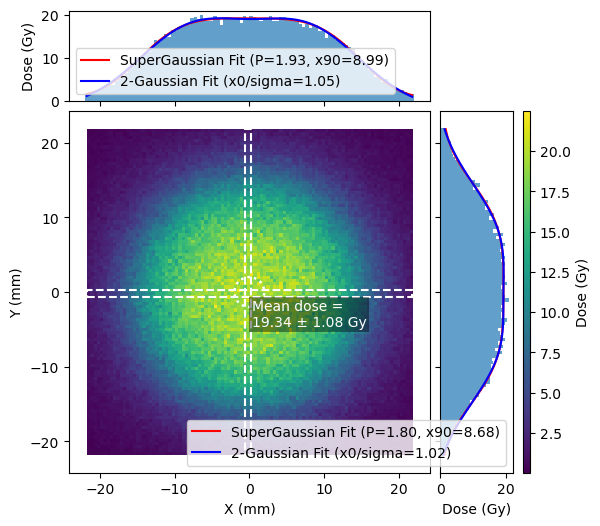

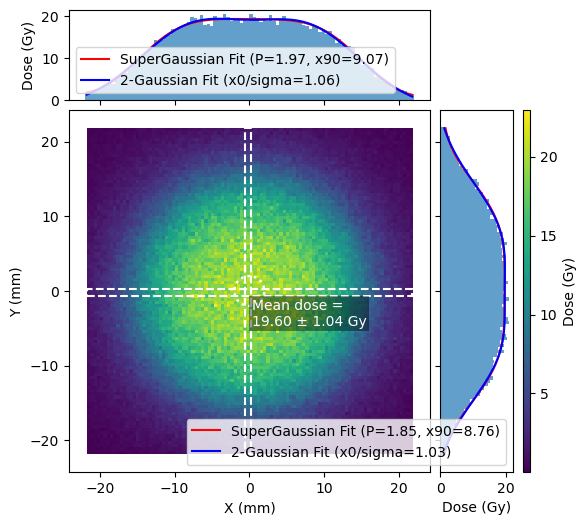

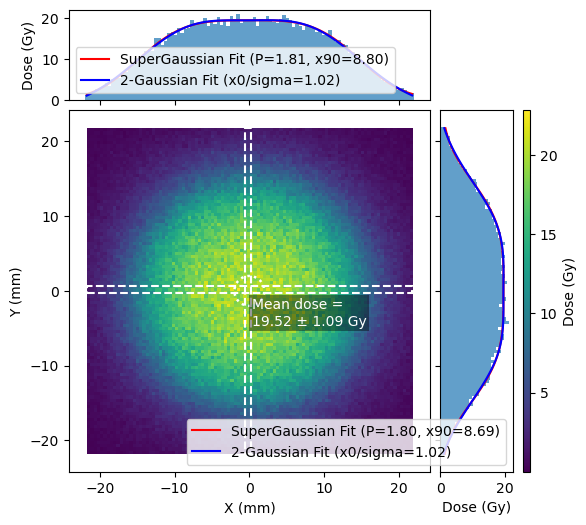

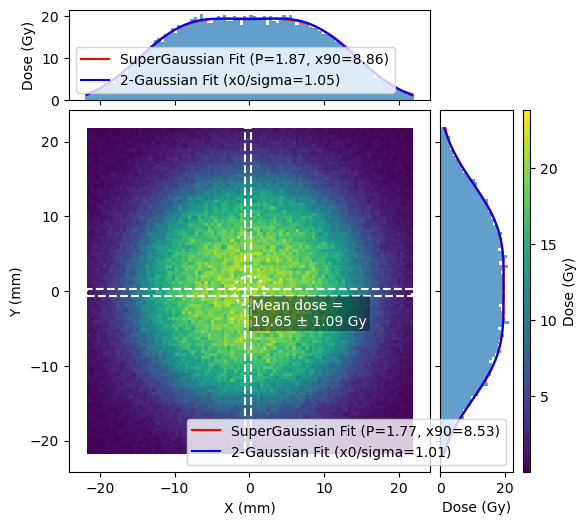

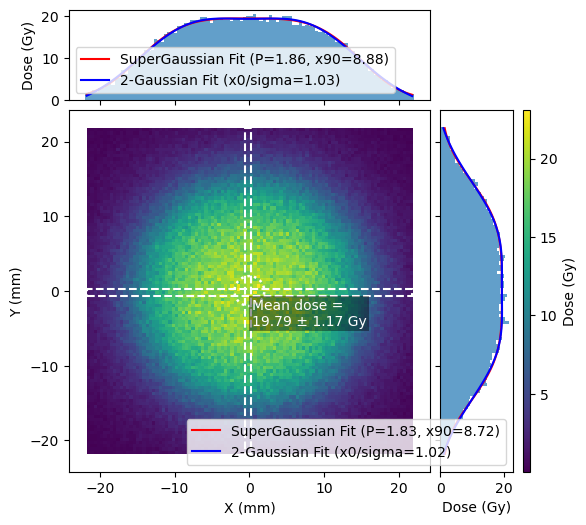

...

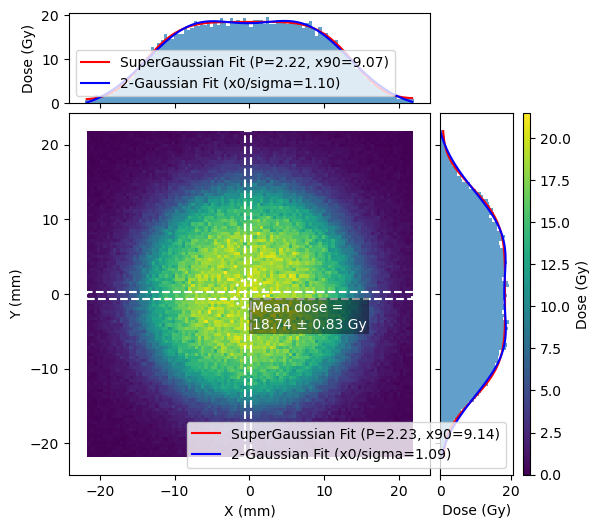

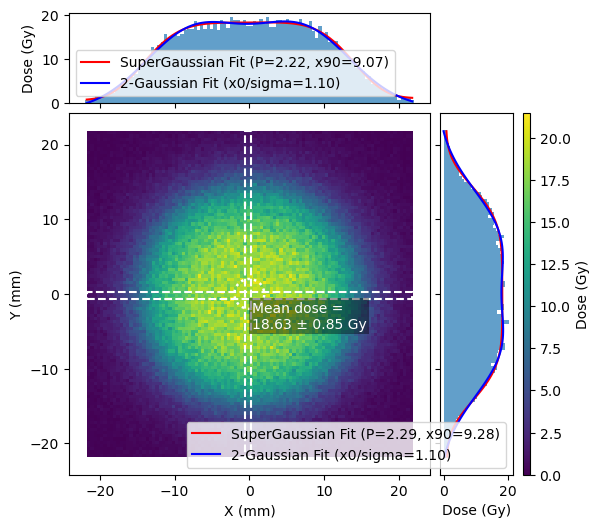

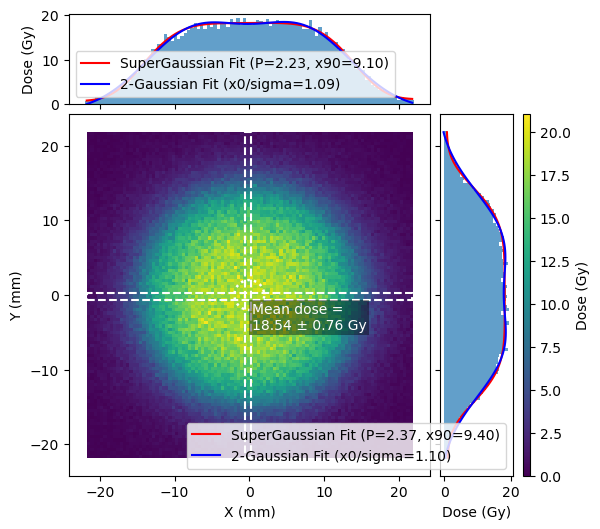

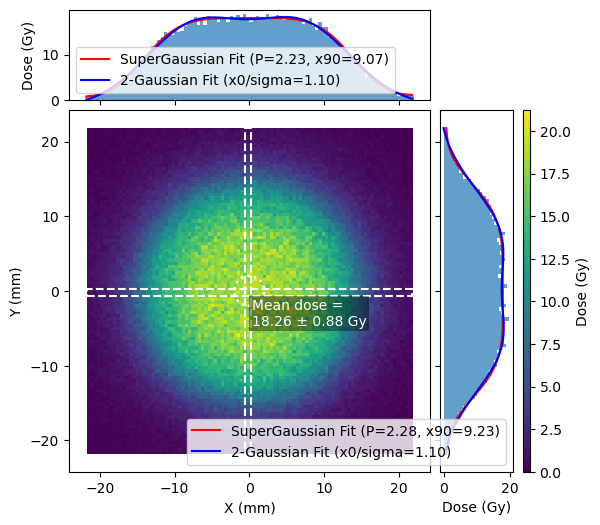

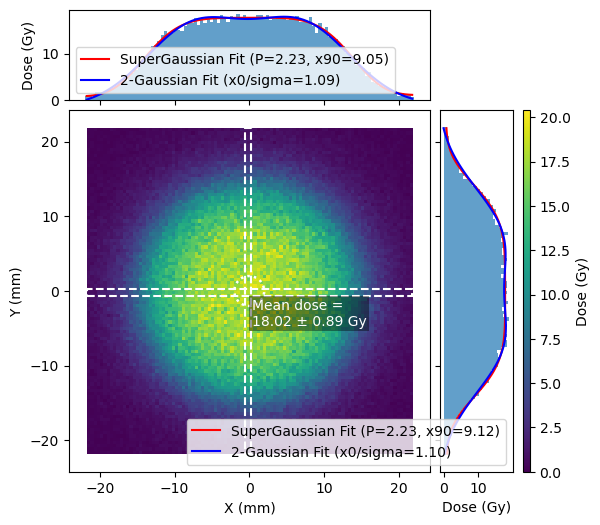

In [13]:
def get_bin_edges(dim):
    return np.linspace(0, dim.n_bins * dim.bin_width, dim.n_bins + 1)

chargenC = 67
csv_path = "CLARA_experiments/250Q_full.csv"
fig_dir = "CLARA_output_figs"
# dose_file = "data/topas/DoseAtTank"+str(dose_depth)+ "_"+ output_filename+".csv"
dose_file = "data/topas/DoseAtTank83_"+output_filename + ".csv"

os.makedirs(fig_dir, exist_ok=True)

existing_csv_entries = set()

if os.path.exists(csv_path):
    with open(csv_path, "r", newline="") as f:
        reader = csv.reader(f)
        next(reader, None)  # skip header
        for row in reader:
            if row:
                existing_csv_entries.add(round(float(row[0]), 1))

write_header = not os.path.exists(csv_path) or os.path.getsize(csv_path) == 0

with open(csv_path, "a", newline="") as f:
    writer = csv.writer(f)

    if write_header:
        writer.writerow([
            "depth",
            "cx", "cy",
            "dose_centre",
            "P_x", "P_y",
            "r90_x", "r90_y",
            "ratio_x", "ratio_y",
            "dose_std",
            "errPx", "errPy",
            "err_x90_x","err_x90_y",
            "err_ratio_x", "err_ratio_y"
        ])
    

    # peek at the scorer to see if it's multibin in z (depth)
    _raw = BinnedResult(dose_file).data['Sum']
    nz = _raw.shape[2] if _raw.ndim == 3 else 1
    print(nz)
    if nz > 1:
        z_dim = BinnedResult(dose_file).dimensions[2]
        depths = (get_bin_edges(z_dim)[1:] * 10)[::-1]  # back edge of each bin, mm, same length as bin centres
        for i in range(nz):
            depth_i = round(float(depths[i]), 1)
            csv_line_exists = depth_i in existing_csv_entries

            if csv_line_exists:
                print(f"Skipping {depth_i}: CSV entry and image already exist.")
                continue

            x, y, doseMap = getDosemap(
                dose_file, N_particles, dose_depth=depths[i],
                outputFileName=output_filename, acChargenC=chargenC, plot=False, z_index=i
            )
            fig, cx, cy, dose_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, dose_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1( doseMap, "RCF",x, y,strip_width=2)

            # plt.savefig(os.path.join(fig_dir, output_filename + f"_z{depth_i:.1f}mm_dose_map.png"))
            # plt.close(fig)

            writer.writerow([
                depth_i,
                cx, cy,
                dose_centre,
                Px, Py,
                x90_x, x90_y,
                ratio_x, ratio_y,
                dose_std,
                errPx, errPy,
                err_x90_x, err_x90_y
            ])
            existing_csv_entries.add(depth_i)

    else:
        x, y, doseMap = getDosemap(
            dose_file, N_particles, dose_depth, output_filename, acChargenC=chargenC, plot=False
        )
        fig, cx, cy, dose_centre, Px, Py, x90_x, x90_y, ratio_x, ratio_y, dose_std, errPx, errPy, err_x90_x, err_x90_y, err_ratio_x, err_ratio_y = plot_dose1( doseMap, "RCF",x, y)
 
        writer.writerow([
            5.9,
            cx, cy,
            dose_centre,
            Px, Py,
            x90_x, x90_y,
            ratio_x, ratio_y,
            dose_std,
            errPx, errPy,
            err_x90_x, err_x90_y,
            err_ratio_x, err_ratio_y
        ])
        plt.savefig(os.path.join(fig_dir, output_filename + '_5.9mm_dose_map.png'))